In [7]:
import torch
from torchvision import models
from torchvision import transforms

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

In [8]:
model = models.detection.fasterrcnn_resnet50_fpn(
    weights=models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)

model.eval()
transform = transforms.Compose([
    transforms.ToTensor()
])

In [9]:
COCO_INSTANCE_CATEGORY_NAMES = [
'__background__','person','bicycle','car','motorcycle','airplane','bus',
'train','truck','boat','traffic light','fire hydrant','N/A','stop sign',
'parking meter','bench','bird','cat','dog','horse','sheep','cow',
'elephant','bear','zebra','giraffe','N/A','backpack','umbrella','N/A',
'N/A','handbag','tie','suitcase','frisbee','skis','snowboard',
'sports ball','kite','baseball bat','baseball glove','skateboard',
'surfboard','tennis racket','bottle','N/A','wine glass','cup','fork',
'knife','spoon','bowl','banana','apple','sandwich','orange','broccoli',
'carrot','hot dog','pizza','donut','cake','chair','couch',
'potted plant','bed','N/A','dining table','N/A','N/A','toilet',
'N/A','tv','laptop','mouse','remote','keyboard','cell phone',
'microwave','oven','toaster','sink','refrigerator','N/A','book',
'clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

In [10]:
def detect_objects(image_path):

    image = Image.open(image_path).convert("RGB")

    image_tensor = transform(image)

    with torch.no_grad():
        prediction = model([image_tensor])[0]

    fig, ax = plt.subplots(figsize=(12,8))
    ax.imshow(image)

    for box, score, label in zip(
        prediction["boxes"],
        prediction["scores"],
        prediction["labels"]
    ):

        if score > 0.8:

            xmin, ymin, xmax, ymax = box

            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )

            ax.add_patch(rect)

            ax.text(
                xmin,
                ymin,
                f"{COCO_INSTANCE_CATEGORY_NAMES[label]} {score:.2f}",
                color='white',
                fontsize=10,
                bbox=dict(facecolor='red', alpha=0.7)
            )

    return fig

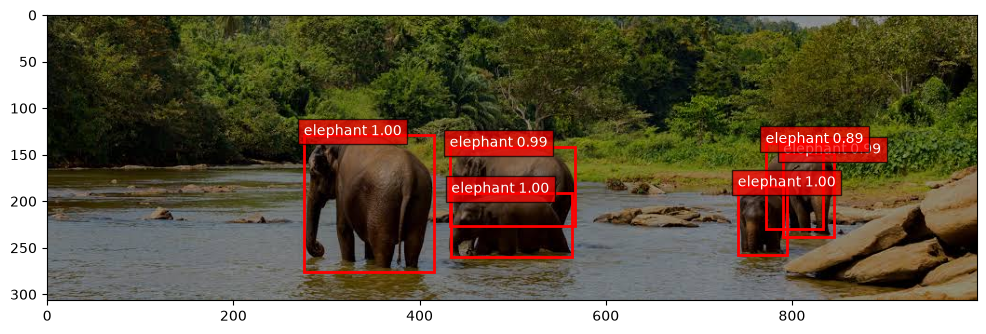

Saved -> ../../outputs/predictions/image1.jpg


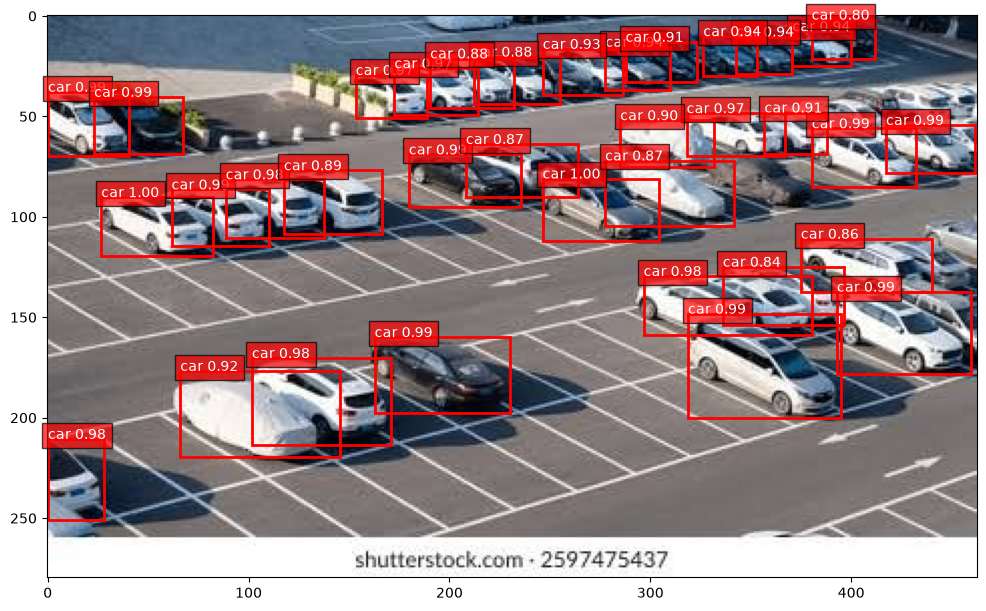

Saved -> ../../outputs/predictions/image2.jpg


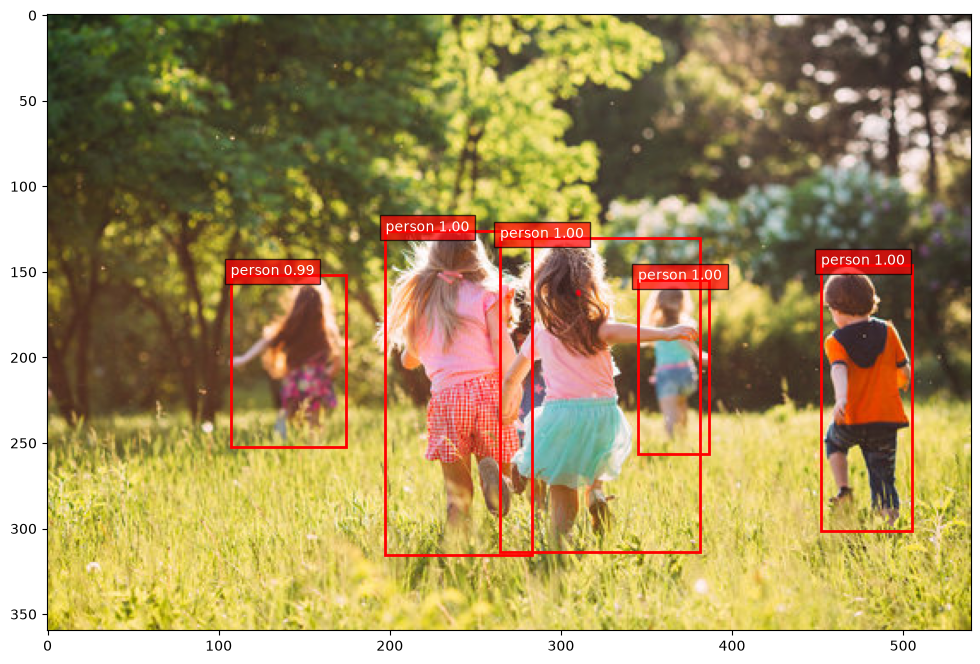

Saved -> ../../outputs/predictions/image3.jpg


In [12]:
image_folder = "../../datasets/object_detection"
output_folder = "../../outputs/predictions"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(image_folder):

    if file.endswith((".jpg", ".png", ".jpeg")):

        image_path = os.path.join(image_folder, file)

        fig = detect_objects(image_path)

        save_path = os.path.join(output_folder, file)

        fig.savefig(save_path, bbox_inches="tight")

        plt.show()

        plt.close(fig)

        print(f"Saved -> {save_path}")